## Imports & Tested Version 

In [ ]:
import sys, torch, scprep
sys.path.append('../')
import warnings; warnings.filterwarnings('ignore')
from torch import optim
import torchvision; from torchvision import datasets, transforms
import numpy as np
import matplotlib; import matplotlib.pyplot as plt
import graphtools as gt
import networkx as nx
import scipy
from torch import nn
from abc import abstractmethod
from typing import List, Callable, Union, Any, TypeVar, Tuple

In [ ]:
print ('Python', sys.version)
print ('torch', torch.__version__)
print ('torchvision', torchvision.__version__)
print ('scprep', scprep.__version__)
print ('numpy', np.__version__)
print ('matplotlib', matplotlib.__version__)

## Load MNIST data

In [ ]:
# Load MNIST and normalize for tanh activation [-1,1]
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
mnist = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

data_all = mnist.data.numpy()
data_all = data_all / 255
data_all = (data_all * 2) - 1 # norm
labels = mnist.train_labels.numpy()

In [ ]:
# pick single digit
digit = 5
idx_digit = mnist.train_labels.numpy() == digit
data_digit = data_all[idx_digit,]
data_digit = np.reshape(data_digit, (data_digit.shape[0], -1))
print(data_digit.shape)

## AAnet

### functions for finding laplacian extrema and loss. AAnet Model definition 

In [ ]:
def get_laplacian_extrema(data, n_extrema, knn=10, subsample=True):
    '''
    Finds the 'Laplacian extrema' of a dataset.  The first extrema is chosen as
    the point that minimizes the first non-trivial eigenvalue of the Laplacian graph
    on the data.  Subsequent extrema are chosen by first finding the unique non-trivial
    non-negative vector that is zero on all previous extrema while at the same time
    minimizing the Laplacian quadratic form, then taking the argmax of this vector.
    '''
    
    if subsample and data.shape[0] > 10000:
        data = data[np.random.choice(data.shape[0], 10000, replace=False), :]
    G = gt.Graph(data, use_pygsp=True, decay=None, knn=knn)
   
    # We need to convert G into a NetworkX graph to use the Tracemin PCG algorithm 
    G_nx = nx.convert_matrix.from_scipy_sparse_array(G.W)
    fiedler = nx.linalg.algebraicconnectivity.fiedler_vector(G_nx, method='tracemin_pcg')

    # Combinatorial Laplacian gives better results than the normalized Laplacian
    L = nx.laplacian_matrix(G_nx)
    first_extrema = np.argmax(fiedler)
    extrema = [first_extrema]
    extrema_ordered = [first_extrema]

    init_lanczos = fiedler
    init_lanczos = np.delete(init_lanczos, first_extrema)
    for i in range(n_extrema - 1):
        # Generate the Laplacian submatrix by removing rows/cols for previous extrema
        indices = range(data.shape[0])
        indices = np.delete(indices, extrema)
        ixgrid = np.ix_(indices, indices)
        L_sub = L[ixgrid] 

        # Find the smallest eigenvector of our Laplacian submatrix
        eigvals, eigvecs = scipy.sparse.linalg.eigsh(L_sub, k=1, which='SM', v0=init_lanczos)

        # Add it to the sorted and unsorted lists of extrema
        new_extrema = np.argmax(np.abs(eigvecs[:,0]))
        init_lanczos = eigvecs[:,0]
        init_lanczos = np.delete(init_lanczos, new_extrema)
        shift = np.searchsorted(extrema_ordered, new_extrema)
        extrema_ordered.insert(shift, new_extrema + shift)
        extrema.append(new_extrema + shift)

    return extrema

In [ ]:
def train_epoch(model, data_loader, optimizer, epoch, gamma_reconstruction=1.0, gamma_archetypal=1.0, gamma_extrema=1.0):
    loss = 0
    reconstruction_loss = 0
    archetypal_loss = 0
    extrema_loss = 0

    for idx, data in enumerate(data_loader):
        
        # if input is list, then data_loader contains features and target
        # assume first input is features based on data_loader structure
        if isinstance(data, list):
            batch_features = data[0]
        else:
            batch_features = data
        
        # if there are extrema, add diffusion extrema to beginning of each batch
        # first n_archetypes samples are used in extrema loss
        if model.diffusion_extrema is not None:
            batch_features = torch.cat((model.diffusion_extrema.view(-1, model.input_shape),
                                    batch_features.view(-1, model.input_shape)), 0)
            
        # reshape mini-batch data to [N, input_shape] matrix
        batch_features = batch_features.view(-1, model.input_shape)
        
        # load it to the active device
        batch_features = batch_features.to(model.device)

        # reset the gradients back to zero
        # PyTorch accumulates gradients on subsequent backward passes
        optimizer.zero_grad()

        # compute reconstructions
        output, _in, archetypal_embedding = model(batch_features.float())

        # compute training reconstruction loss
        curr_reconstruction_loss = torch.mean((output - batch_features)**2)
        reconstruction_loss += curr_reconstruction_loss

        # compute training archetypal loss
        curr_archetypal_loss = model.calc_archetypal_loss(archetypal_embedding)
        archetypal_loss += curr_archetypal_loss
        
        # compute training diffusion extrema loss
        if model.diffusion_extrema is not None:
            curr_extrema_loss = model.calc_diffusion_extrema_loss(archetypal_embedding)
            extrema_loss += curr_extrema_loss
        else:
            curr_extrema_loss = 0
            extrema_loss = 0
            
        # extrema penalization decreases over batches and epochs
        # this enables AAnet to learn the correct archetypes if the diffusion extrema are not close
        train_loss = gamma_reconstruction * curr_reconstruction_loss + \
                     gamma_archetypal * curr_archetypal_loss + \
                     gamma_extrema /(epoch * len(data_loader) + (idx+1)) * curr_extrema_loss

        # compute accumulated gradients
        train_loss.backward()

        # perform parameter update based on current gradients
        optimizer.step()

        # add the mini-batch training loss to epoch loss
        loss += train_loss.item()

    # compute the epoch training loss
    loss = loss / len(data_loader)
    reconstruction_loss = reconstruction_loss / len(data_loader)
    archetypal_loss = archetypal_loss / len(data_loader)
    return loss, reconstruction_loss, archetypal_loss

In [ ]:
def train_epoch(model, data_loader, optimizer, epoch, gamma_reconstruction=1.0, gamma_archetypal=1.0, gamma_extrema=1.0):
    loss = 0
    reconstruction_loss = 0
    archetypal_loss = 0
    extrema_loss = 0

    for idx, data in enumerate(data_loader):
        
        # if input is list, then data_loader contains features and target
        # assume first input is features based on data_loader structure
        if isinstance(data, list):
            batch_features = data[0]
        else:
            batch_features = data
        
        # if there are extrema, add diffusion extrema to beginning of each batch
        # first n_archetypes samples are used in extrema loss
        if model.diffusion_extrema is not None:
            batch_features = torch.cat((model.diffusion_extrema.view(-1, model.input_shape),
                                    batch_features.view(-1, model.input_shape)), 0)
            
        # reshape mini-batch data to [N, input_shape] matrix
        batch_features = batch_features.view(-1, model.input_shape)
        
        # load it to the active device
        batch_features = batch_features.to(model.device)

        # reset the gradients back to zero
        # PyTorch accumulates gradients on subsequent backward passes
        optimizer.zero_grad()

        # compute reconstructions
        output, _in, archetypal_embedding = model(batch_features.float())

        # compute training reconstruction loss
        curr_reconstruction_loss = torch.mean((output - batch_features)**2)
        reconstruction_loss += curr_reconstruction_loss

        # compute training archetypal loss
        curr_archetypal_loss = model.calc_archetypal_loss(archetypal_embedding)
        archetypal_loss += curr_archetypal_loss
        
        # compute training diffusion extrema loss
        if model.diffusion_extrema is not None:
            curr_extrema_loss = model.calc_diffusion_extrema_loss(archetypal_embedding)
            extrema_loss += curr_extrema_loss
        else:
            curr_extrema_loss = 0
            extrema_loss = 0
            
        # extrema penalization decreases over batches and epochs
        # this enables AAnet to learn the correct archetypes if the diffusion extrema are not close
        train_loss = gamma_reconstruction * curr_reconstruction_loss + \
                     gamma_archetypal * curr_archetypal_loss + \
                     gamma_extrema /(epoch * len(data_loader) + (idx+1)) * curr_extrema_loss

        # compute accumulated gradients
        train_loss.backward()

        # perform parameter update based on current gradients
        optimizer.step()

        # add the mini-batch training loss to epoch loss
        loss += train_loss.item()

    # compute the epoch training loss
    loss = loss / len(data_loader)
    reconstruction_loss = reconstruction_loss / len(data_loader)
    archetypal_loss = archetypal_loss / len(data_loader)
    return loss, reconstruction_loss, archetypal_loss

In [ ]:
class AAnet_vanilla(nn.Module):
    def __init__(
        self,
        input_shape,
        n_archetypes=4,
        noise=0,
        layer_widths=[128, 128],
        activation_out="tanh",
        simplex_scale=1,
        device=None,
        diffusion_extrema=None,
        **kwargs
    ):
        super().__init__()

        self.input_shape = input_shape
        self.n_archetypes = n_archetypes
        self.noise = noise
        self.layer_widths = layer_widths
        self.activation_out = activation_out
        self.simplex_scale = simplex_scale
        self.diffusion_extrema = diffusion_extrema
        
        if device is None:
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        else:
            self.device = device

        # ---------------------------
        # Encoder network
        # ---------------------------
        self.encoder_layers = nn.ModuleList()
        for i, width in enumerate(layer_widths):
            in_features = input_shape if i == 0 else layer_widths[i - 1]
            self.encoder_layers.append(nn.Linear(in_features, width))

        # Last encoder layer → latent dims = n_archetypes - 1
        self.encoder_layers.append(nn.Linear(layer_widths[-1], n_archetypes - 1))

        # ---------------------------
        # Decoder network
        # ---------------------------
        self.decoder_layers = nn.ModuleList()
        decoder_widths = layer_widths[::-1]

        for i, width in enumerate(decoder_widths):
            in_features = n_archetypes - 1 if i == 0 else decoder_widths[i - 1]
            self.decoder_layers.append(nn.Linear(in_features, width))

        # Last decoder layer → reconstruct input
        self.decoder_layers.append(
            nn.Linear(decoder_widths[-1], input_shape)
        )

        # Precompute archetypal simplex
        self.archetypal_simplex = self.get_n_simplex(n_archetypes, simplex_scale)

        self.to(self.device)

    # ============================================================
    # Utility functions (migrated from BaseAAnet)
    # ============================================================

    def get_n_simplex(self, n=2, scale=1):
        """Returns an n-simplex centered at the origin."""
        nth = (1/(n-1)*(1-np.sqrt(n))) * np.ones(n-1)
        D = np.vstack([np.eye(n-1), nth]) * scale
        return torch.tensor(D - np.mean(D, axis=0), dtype=torch.float, device=self.device)

    def euclidean_to_barycentric(self, X):
        """Convert Euclidean → barycentric coordinates."""
        simplex = self.archetypal_simplex

        T = torch.zeros((X.shape[1], X.shape[1])).to(self.device)
        for i in range(X.shape[1]):
            for j in range(X.shape[1]):
                T[i, j] = simplex[i, j] - simplex[-1, j]

        T_inv = torch.inverse(T).float().to(self.device)

        X_bary = torch.einsum("ij,bj->bi", T_inv, X - simplex[-1])
        X_bary = torch.cat(
            [X_bary, (1 - torch.sum(X_bary, dim=1, keepdim=True))],
            dim=1
        )
        return X_bary

    def dist_to_simplex(self, X_bary):
        """Distance penalty for barycentric coords outside simplex."""
        return torch.sum(torch.clamp(-X_bary, min=0), dim=1)

    def calc_archetypal_loss(self, archetypal_embedding):
        """Archetypal loss = MSE of distance to simplex."""
        X_bary = self.euclidean_to_barycentric(archetypal_embedding)
        return torch.mean(self.dist_to_simplex(X_bary) ** 2)

    def calc_diffusion_extrema_loss(self, archetypal_embedding):
        """MSE loss between diffusion extrema and simplex vertices."""
        X_bary = self.euclidean_to_barycentric(archetypal_embedding)
        return torch.mean(
            (X_bary[:self.n_archetypes, :] -
             torch.eye(self.n_archetypes, device=self.device)) ** 2
        )

    # ============================================================
    # Encoder / Decoder
    # ============================================================

    def encode(self, x):
        for layer in self.encoder_layers[:-1]:
            x = torch.relu(layer(x))
        return self.encoder_layers[-1](x)  # no activation

    def decode(self, z):
        for layer in self.decoder_layers[:-1]:
            z = torch.relu(layer(z))
        return self.decoder_layers[-1](z)  # no activation

    # ============================================================
    # Forward
    # ============================================================

    def forward(self, x) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Returns:
            recons → reconstructed data
            x → original input
            archetypal_embedding → latent embedding
        """
        z = self.encode(x)
        archetypal_embedding = z.clone()

        if self.noise > 0:
            z = z + torch.normal(0., self.noise, size=z.shape).to(self.device)

        recons = self.decode(z)

        return recons, x, archetypal_embedding


### Run AAnet

In [ ]:
N_ARCHETYPES = 3
data_loader = torch.utils.data.DataLoader(data_digit, batch_size=256, shuffle=True, num_workers=4)

# warm-start model with graph-based extrema for improved results
extrema = torch.Tensor(get_laplacian_extrema(data_digit, n_extrema=N_ARCHETYPES))
extrema = torch.Tensor(data_digit[extrema.numpy().astype(int)])

In [ ]:
device = torch.device('cpu')
model = AAnet_vanilla(noise=0.05, layer_widths=[256, 128],
                             n_archetypes=N_ARCHETYPES, 
                             input_shape=data_digit.shape[1],
                             device=device, diffusion_extrema=extrema)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
n_row = 12
n_col = 6
fig, axes = plt.subplots(n_row, n_col, figsize=(n_col*2, n_row*2))

for i, ax in enumerate(axes.flatten()):
    if i == 0:
        r_loss = a_loss = 0

        title='Untrained'
    else:
        # gamma_extrema parameter weights how informative graph-based extrema are to model
        # higher gamma_extrema = more pushing AAnet to learn the archetypes learned from the graph-based approach
        loss, r_loss, a_loss=train_epoch(model, data_loader, optimizer, epoch=i, gamma_extrema=1.0)
        title='Epoch {}\nR={:.2f} A:{:.2f}'.format(i, r_loss, a_loss)

    archetypal_embedding = model.encode(torch.Tensor(data_digit))

    scprep.plot.scatter2d(archetypal_embedding.detach().cpu().numpy(), title=title, ax=ax)
    scprep.plot.scatter2d(model.get_n_simplex(model.n_archetypes).cpu().numpy(), ax=ax)
    ax.set_xlim(-1, 1.25)
    ax.set_ylim(-1, 1.25)

fig.tight_layout()

### Visualize latent space

In [12]:
archetypal_embedding = model.encode(torch.Tensor(data_digit))
vertices_embedding = model.get_n_simplex(n=3)
barycentric_archetypal_embedding = model.euclidean_to_barycentric(archetypal_embedding).detach().numpy()

<Axes: >

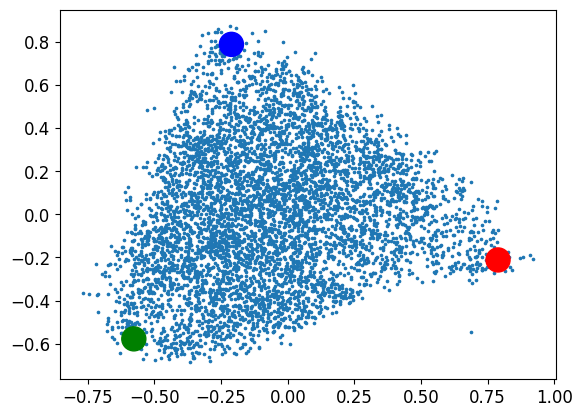

In [13]:
fig, ax = plt.subplots()
scprep.plot.scatter2d(archetypal_embedding.detach().numpy(), ax=ax)
scprep.plot.scatter2d(vertices_embedding.detach().numpy(), ax=ax, c=['red', 'blue', 'green'], s=300)

### Visualize average of 20 images nearest each archetype

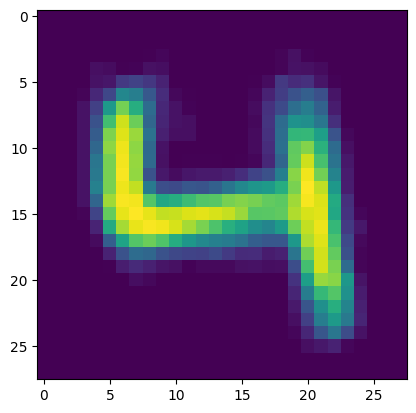

In [14]:
images_close_to_red_archetype_idx = np.argsort(barycentric_archetypal_embedding[:, 0])[::-1][:20]
images_close_to_red_archetype = data_digit[images_close_to_red_archetype_idx].reshape(20, 28, 28)
plt.imshow(images_close_to_red_archetype.mean(axis=0))

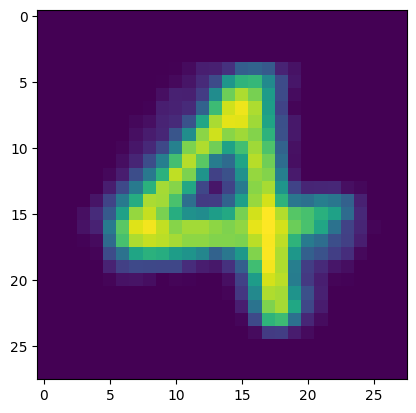

In [15]:
images_close_to_blue_archetype_idx = np.argsort(barycentric_archetypal_embedding[:, 1])[::-1][:20]
images_close_to_blue_archetype = data_digit[images_close_to_blue_archetype_idx].reshape(20, 28, 28)
plt.imshow(images_close_to_blue_archetype.mean(axis=0))

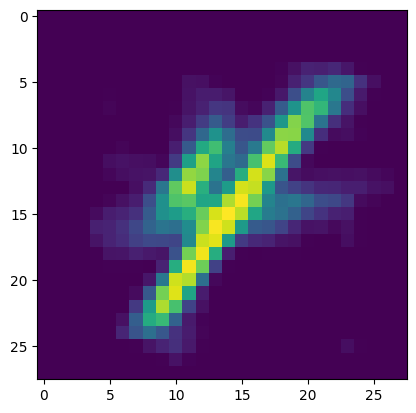

In [16]:
images_close_to_green_archetype_idx = np.argsort(barycentric_archetypal_embedding[:, 2])[::-1][:20]
images_close_to_green_archetype = data_digit[images_close_to_green_archetype_idx].reshape(20, 28, 28)
plt.imshow(images_close_to_green_archetype.mean(axis=0))